In [1]:
import numpy as np
import vsigmoid
import vtanh
import torch
import inspect
import model_forward
import matplotlib.pyplot as plt
import bintrans

In [3]:
folder_name = input('模型：')

模型：model5


In [4]:
model_path = '../trained_model/' + folder_name + '/train/' 

In [5]:
model = torch.load(model_path + 'my_model.pth')
parameters = {}
for name, param in model.named_parameters():
    parameters[name] = param.detach().numpy()

In [6]:
xy = np.load(model_path + 'xy_dict.npy', allow_pickle=True).item()

In [7]:
x = xy['train_x'][0, :, :]
x_ts = torch.from_numpy(x).type(torch.float32).reshape(1, 30, 8)

In [11]:
x

array([[0.97567568, 0.0774    , 0.93164566, 0.86394173, 0.1437212 ,
        0.10046626, 0.03759826, 0.04134325],
       [0.97675676, 0.0772    , 0.93164594, 0.86394173, 0.1437212 ,
        0.10046626, 0.03759826, 0.04134325],
       [0.97297297, 0.0772    , 0.93164594, 0.86394173, 0.1437212 ,
        0.10046626, 0.03759826, 0.04134325],
       [0.97459459, 0.0769    , 0.93164636, 0.86394173, 0.1437212 ,
        0.10046626, 0.03759826, 0.04134325],
       [0.97567568, 0.077     , 0.93164622, 0.86394173, 0.1437212 ,
        0.10046626, 0.03759826, 0.04134325],
       [0.97243243, 0.0766    , 0.93164678, 0.86394173, 0.1437212 ,
        0.10046626, 0.03759826, 0.04134325],
       [0.97513514, 0.0766    , 0.93164678, 0.86394173, 0.1437212 ,
        0.10046626, 0.03759826, 0.04134325],
       [0.97891892, 0.0763    , 0.93164719, 0.86394173, 0.1437212 ,
        0.10046626, 0.03759826, 0.04134325],
       [0.97405405, 0.0762    , 0.93164733, 0.86394173, 0.1437212 ,
        0.10046626, 0.037598

In [46]:
scale = 2 ** 13

In [47]:
vlstm = model_forward.Vlstm(x, parameters, scale)
plstm = model_forward.Plstm(x, parameters)

In [48]:
all_result_v = vlstm.forward(30)
all_result_p = plstm.forward(30)

时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29


In [49]:
r_v = []
r_p = []
for i in range(100):
    x = xy['train_x'][i, :, :]
    vlstm = model_forward.Vlstm(x, parameters, scale)
    plstm = model_forward.Plstm(x, parameters)
    all_result_v = vlstm.forward(30)
    all_result_p = plstm.forward(30)
    result_v = all_result_v['result']
    result_p = all_result_p['result']
    r_v.append(result_v)
    r_p.append(result_p)

时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29


时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29


时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29


时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0


时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29
时间步：0
时间步：1
时间步：2
时间步：3
时间步：4
时间步：5
时间步：6
时间步：7
时间步：8
时间步：9
时间步：10
时间步：11
时间步：12
时间步：13
时间步：14
时间步：15
时间步：16
时间步：17
时间步：18
时间步：19
时间步：20
时间步：21
时间步：22
时间步：23
时间步：24
时间步：25
时间步：26
时间步：27
时间步：28
时间步：29


In [50]:
r_p[0]

array([0.9741446], dtype=float32)

In [51]:
array_p = np.array((r_p[0]))
array_v = np.array((r_v[0]))
for i in range(len(r_p)-1):
    array_p = np.concatenate((array_p, r_p[i+1]))
    array_v = np.concatenate((array_v, r_v[i+1]))

In [52]:
array_p = array_p.reshape(-1, 1)
array_v = (array_v / scale).reshape(-1, 1)
pverrro = array_p - array_v
outdata = np.concatenate((array_p, array_v, pverrro), axis=1)

In [53]:
import pandas as pd
outpd = pd.DataFrame(outdata)

In [55]:
outpd.to_excel('outdata13.xlsx')

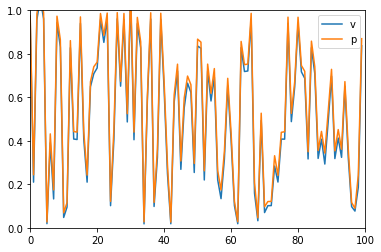

In [22]:
plt.figure()
plt.plot([i/scale for i in r_v], label='v')
plt.plot(r_p, label='p')
plt.legend()
plt.axis([0, 100, 0, 1])
plt.show()

In [26]:
x_ts * scale

tensor([[[3996.3677,  317.0304, 3816.0208, 3538.7053,  588.6820,  411.5098,
           154.0025,  169.3419],
         [4000.7957,  316.2112, 3816.0217, 3538.7053,  588.6820,  411.5098,
           154.0025,  169.3419],
         [3985.2974,  316.2112, 3816.0217, 3538.7053,  588.6820,  411.5098,
           154.0025,  169.3419],
         [3991.9395,  314.9824, 3816.0234, 3538.7053,  588.6820,  411.5098,
           154.0025,  169.3419],
         [3996.3677,  315.3920, 3816.0229, 3538.7053,  588.6820,  411.5098,
           154.0025,  169.3419],
         [3983.0833,  313.7536, 3816.0251, 3538.7053,  588.6820,  411.5098,
           154.0025,  169.3419],
         [3994.1536,  313.7536, 3816.0251, 3538.7053,  588.6820,  411.5098,
           154.0025,  169.3419],
         [4009.6519,  312.5248, 3816.0269, 3538.7053,  588.6820,  411.5098,
           154.0025,  169.3419],
         [3989.7253,  312.1152, 3816.0276, 3538.7053,  588.6820,  411.5098,
           154.0025,  169.3419],
         [3994.1536

In [23]:
def compare(key):
    value_v = all_result_v[key] / scale
    value_p = all_result_p[key]
    erro = 100*(value_v - value_p) / value_p
    print(f'浮点模型：{value_p}, 定点模型：{value_v}， 误差：'+ format(erro[0], '.2f') + '%')

In [31]:
compare('result')

浮点模型：[0.92576253], 定点模型：[0.95703125]， 误差：3.38%


In [32]:
0.957 * scale

3919.872

In [ ]:
all_result_p['result']

In [ ]:
ref = all_result_v['h'][1, 0, :]

In [ ]:
gate_reg = input("16进制结果：")
index = input("这是第几个结果：")
index = int(index)
dec_temp = bintrans.any2dec(gate_reg, num=16, wid=16)
print('--------------\n以上忽略，下面是结果\n--------------')
if dec_temp == ref[index]:
    print('√')
else:
    print('×')
    print(f'{dec_temp} != {ref[index]}')

In [ ]:
ref

In [ ]:
model(x_ts)

In [8]:
all_result_v['result']

array([-4.], dtype=float32)

In [9]:
all_result_v['h'].shape

(30, 2, 64)

In [12]:
all_result_v['h'][28, 1, :]

array([-22., -13., -31.,  -4., -36., -46., -30., -13., -27., -14., -30.,
       -13.,  -3., -13., -24., -18., -29., -48., -28., -20., -17., -23.,
       -20., -49., -32.,  -4., -25., -27., -15., -14., -24., -21., -22.,
       -39., -22., -18., -41., -31., -33., -31., -20., -34., -29., -26.,
       -13., -21., -22., -23., -20., -24.,  -3., -27., -17., -31., -17.,
       -17., -32., -26., -15., -26., -24., -12., -13., -12.])

In [ ]:
(512-21) / 4

第一个cell的仿真结果

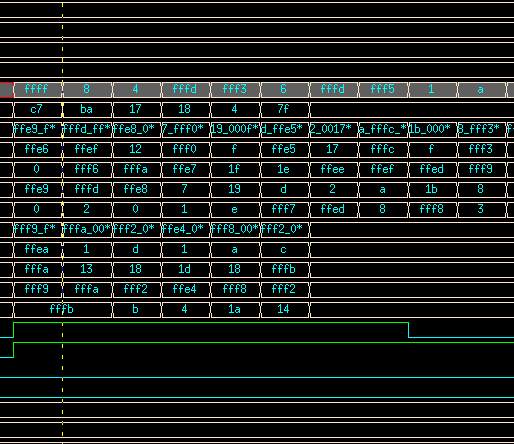

In [ ]:
lis = ['ffff', '8', '4', 'fffd', 'fff3', '6', 'fffd', 'fff5', '1', 'a']

In [ ]:
for l in lis:
    bintrans.any2dec(l, 16, 16)

In [ ]:
all_result_v['gate'].shape

In [ ]:
ref = all_result_v['h'][0, 1, :]

In [ ]:
ref

In [14]:
bintrans.any2dec('fffe', 16, 16)

1111111111111110
-2


-2

In [ ]:
199 * -30 / 256

In [ ]:
wh = ['ffe9', 'fffd', 'ffe8', '7', '19', 'd', '2']
h = ['ffff', '8', '4', 'fffd', 'fff3', '6', 'fffd']
hw = ['0', 'ffff', 'fffe', '0', 'ffff', 'ffff', '0']
a = []
b = []
c = []
for i in range(len(wh)):
    a.append(bintrans.any2dec(wh[i], 16, 16))
    b.append(bintrans.any2dec(h[i], 16, 16))
    c.append(bintrans.any2dec(hw[i], 16, 16))

In [79]:
vr = bintrans.any2dec('3ad', 16, 16)
pr = all_result_p['result'][0]
pv = all_result_v['result'][0]
print('-----------------------------------------')
print(f'python浮点模型的结果：{pr} \n\
python定点模型的结果：无小数点[{int(pv)}] 有小数点[{pv/scale}] \n\
verilog模型的结果   ：无小数点[{vr}] 有小数点[{vr/scale}]')

1110101101
941
-----------------------------------------
python浮点模型的结果：0.11817605793476105 
python定点模型的结果：无小数点[941] 有小数点[0.1148681640625] 
verilog模型的结果   ：无小数点[941] 有小数点[0.1148681640625]


In [4]:
scale = 2**29

In [6]:
a = int(0.8 * scale)

In [16]:
a_b = bintrans.dec2bnr(a, 32)

In [19]:
a_d = int(a_b, 2)

In [20]:
hex(a_d)

'0x19999999'

In [21]:
a_b

'00011001100110011001100110011001'

In [40]:
2**40 * 1/(12000*3600)

25451.65805037037

In [39]:
2**15

32768

In [48]:
12000 * 3600 * 0.7

30239999.999999996

In [46]:
2**26

67108864

In [ ]:
1110011111

In [49]:
3*(16**2) + 9*16 + 15

927